<a href="https://colab.research.google.com/github/jagadeeshy429-yt/Suicide-Risk-Assessment-Agent/blob/main/crop_recommendation(39).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [ ]:
from xgboost import XGBClassifier

In [ ]:
pip install xgboost

In [ ]:
df = pd.read_csv("/content/Crop_recommendation.csv")

print(df.head())
print(df.info())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


In [ ]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.drop_duplicates(inplace=True)

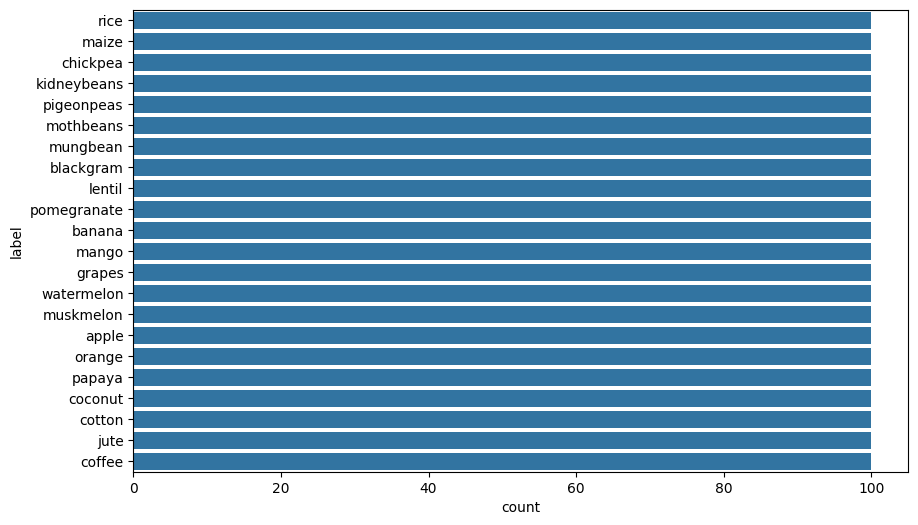

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(y='label', data=df)
plt.show()

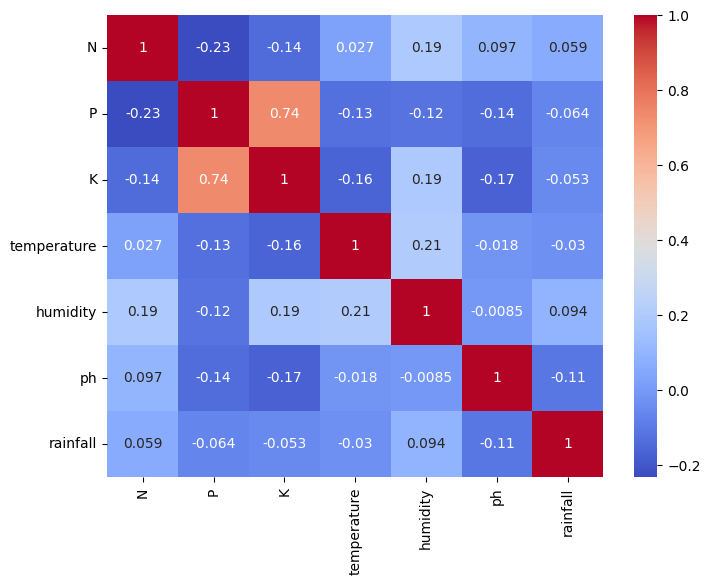

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = df.drop('label', axis=1)

In [ ]:
y = df['label']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Re-assign y from the original DataFrame column to ensure it contains string labels
y_original_labels = df['label']
le.fit(y_original_labels) # Fit the encoder on string labels

# Transform the original y into numerical labels for model training
y = le.transform(y_original_labels)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print(rf_pred)

[16  1  6 11 16  3 20  2  1 16 21 19 21 11 13  7  7 12 12  0  2  0 13  9
  0  8 13 21 20  5 12  8  1  5  8  2  7  7  2  8  4 17 12 11 10  8  6 10
  3 14 17 19 18 21 12  2 17 17  5 10 10 13  5  1 17 20 16  4  2 19  1 15
 21 10  1  4 13 14 14 12  5 21 15  9 12 19 16  6  4 17 13 14 13  6  8  7
  6  3  8 21 15 19 16 18 18  7  9 10 20 20  0 14 14  7 20 15  2 10  1 16
 16  3 11 12 11 10  1 19  4 14  6  3  8 14 13 11  0  3 20 11  6  8 19 12
 20 17  1 16 18 10 11  3  6 21 13 11 18 15  0 14  2  3 11 11  9  5 16 11
  7 19  0  4 15  7  6 10 18  3 11 13  0 15  6 21 15 21 16 21  5  9  0  3
  2  5 15  5  0  7  8 17  4  7 21 14 19 18 14 10 17 15  3  0 11  3  1 19
 19 11 16  8  6  6 11  7 14 10 18 17 14  0  1 20  3 11 20 16  2  4 20  7
  9  6 14 14  4  0 10 17 19  3  9  9 18  8 15 19  2  3 15 12  3 21  3 19
 12 13  6  8  0  9  4 17  5  9  4  4  2 10  9 14  5  6  7  5  2 13 10 21
 19  0 16 12  8  1 10 14  2 13 21 18 10  1  0  1 21  2  9 20 17  1  9  1
 15 15 16 11  1 18  8  0 10 15  4 17  8  6 16 16  2

In [ ]:
svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
print(xgb_pred)

[16  1  6 11 16  3 20  2  1 16 21 19 21 11 13  7  7 12 12  0  2  0 13  9
  0  8 13 21 20  5 12  8  1  5  8  2  7  7  2  8  4 17 12 11 10  8  6 10
  3 14 17 19 18 21 12  2 17 17  5 10 10 13  5  1 17 20 16  4  2 19  1 15
 21 10  1  4 13 14 14 12  5 21 15  9 12 19 16  6  4 17 13 14 13  6  8  7
  6  3  8 21 15 19 16 18 18  7  9 10 20 20  0 14 14  7 20 15  2 10  1 16
 16  3 11 12 11 10  1 19  4 14  6  3  8 14 13 11  0  3 20 11  6  8 19 12
 20 17  1 16 18 14 11  3  6 21 13 11 18 15  0 14  2  3 11 11  9  5 16 11
  7 19  0  4 15  7  6 14 18  3  2 13  0 15  6 21 15 21 16 21  5  9  0  3
  2  5 15  5  0  7  8 17  4  7 21 14 19 18 14 13 17 15  3  0 11  3  1 19
 19 11 16  8  6  6 11  7 14 10 18 17 14  0  1  8  3 11 20 16  2  4 20  7
  9  6 14 14  4  0 10 17 19  3  9  9 18  8 15 19  2  3 15 12  3 21  3 19
 12 13  6  8  0  9  4 17  5  9  4  4  2 10  9 14  5  6  7  5  2 13 10 21
 19  0 16 12  8  1 10 14  2 13 21 18 10  1  0  1 21  2  9 20 17  1  9  1
 15 15 16 11  1  2  8  0 10 15  4 17  8  6 16 16  2

In [ ]:
print("RF:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("KNN:", accuracy_score(y_test, knn_pred))
print("MLP:", accuracy_score(y_test, mlp_pred))
print("XGB:", accuracy_score(y_test, xgb_pred))

RF: 0.9954545454545455
SVM: 0.9840909090909091
KNN: 0.9795454545454545
MLP: 0.9886363636363636
XGB: 0.9863636363636363


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

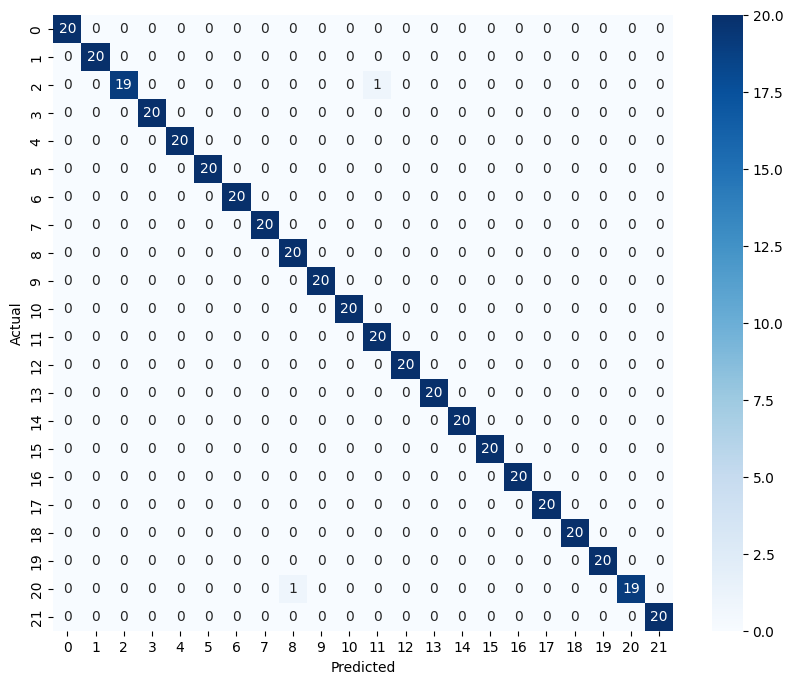

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import joblib

joblib.dump(rf, "crop_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
sample = [[90,42,43,20.87,82.00,6.5,202.93]]

prediction = rf.predict(sample)

crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

model = joblib.load("crop_model.pkl")
scaler = joblib.load("scaler.pkl")
le = joblib.load("label_encoder.pkl")

In [ ]:
N = 90
P = 42
K = 43
temperature = 20.8
humidity = 82
ph = 6.5
rainfall = 203

In [ ]:
import requests

api_key = "YOUR_API_KEY"

city = "Vijayawada"

url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}"

data = requests.get(url).json()

In [ ]:
soil_data = [[90,42,43,20.8,82,6.5,203]]
print()

In [ ]:
if ph < 4 or ph > 9:
    print("Invalid pH value")

In [ ]:
prediction = model.predict(soil_data)

crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
crop_info = {
    "rice":
    {
        "season":"Kharif",
        "water":"High",
        "duration":"120-150 days"
    }
}

In [ ]:
predicted_label_num = crop[0]

try:
    # Attempt to inverse transform to get the string crop name
    predicted_crop_name = le.inverse_transform([predicted_label_num])[0]
except ValueError: # Fallback if inverse_transform fails (e.g., if le is not properly fitted)
    predicted_crop_name = str(predicted_label_num) # Convert to string if it remains numerical

if predicted_crop_name in crop_info:
    print(crop_info[predicted_crop_name])
else:
    print(f"Information for crop '{predicted_crop_name}' (label {predicted_label_num}) is not available in crop_info. Please expand your crop_info dictionary or ensure LabelEncoder is correctly fitted.")

{'season': 'Kharif', 'water': 'High', 'duration': '120-150 days'}


In [ ]:
import pandas as pd

record = {
    "Farmer":"Ramesh",
    "Crop":"Rice",
    "Date":"2026-06-24"
}

df = pd.DataFrame([record])

df.to_csv(
    "cultivation_records.csv",
    mode='a',
    index=False,
    header=False
)

In [ ]:
if N < 50:
    print("Apply Nitrogen Fertilizer")

if P < 40:
    print("Apply Phosphorus Fertilizer")

In [ ]:
if rainfall < 100:
    print("Additional Irrigation Required")
else:
    print("Rainfall Sufficient")

Rainfall Sufficient


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn,
    "MLP": mlp,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    if name in ["Random Forest", "XGBoost"]:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accuracy, precision, recall, f1])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

results_df = results_df.sort_values("Accuracy", ascending=False)

print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.995455   0.995671  0.995455  0.995452
3            MLP  0.988636   0.988745  0.988636  0.988635
4        XGBoost  0.986364   0.987407  0.986364  0.986210
1            SVM  0.984091   0.985610  0.984091  0.984038
2            KNN  0.979545   0.980356  0.979545  0.979283


In [ ]:
results_df.style.background_gradient(cmap='Greens')

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.995455,0.995671,0.995455,0.995452
3,MLP,0.988636,0.988745,0.988636,0.988635
4,XGBoost,0.986364,0.987407,0.986364,0.986210
1,SVM,0.984091,0.985610,0.984091,0.984038
2,KNN,0.979545,0.980356,0.979545,0.979283


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores")

print(cv_scores)

print("\nAverage Accuracy :", cv_scores.mean())

print("Standard Deviation :", cv_scores.std())

Cross Validation Scores
[0.99772727 0.99318182 0.99772727 0.99545455 0.98863636]

Average Accuracy : 0.9945454545454545
Standard Deviation : 0.003401506715249021


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train, y_train)

print("Best Parameters")

print(grid.best_params_)

print("Best Accuracy")

print(grid.best_score_)

best_model = grid.best_estimator_

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Accuracy
0.9960227272727271


In [ ]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

In [ ]:
import numpy as np

sample = X_test.iloc[[0]]

prob = best_model.predict_proba(sample)[0]

top3 = np.argsort(prob)[-3:][::-1]

print("Top 3 Predictions")

for i in top3:

    crop = le.inverse_transform([i])[0]

    print(crop, ":", round(prob[i]*100,2), "%")

Top 3 Predictions
orange : 94.97 %
pomegranate : 4.81 %
coconut : 0.22 %


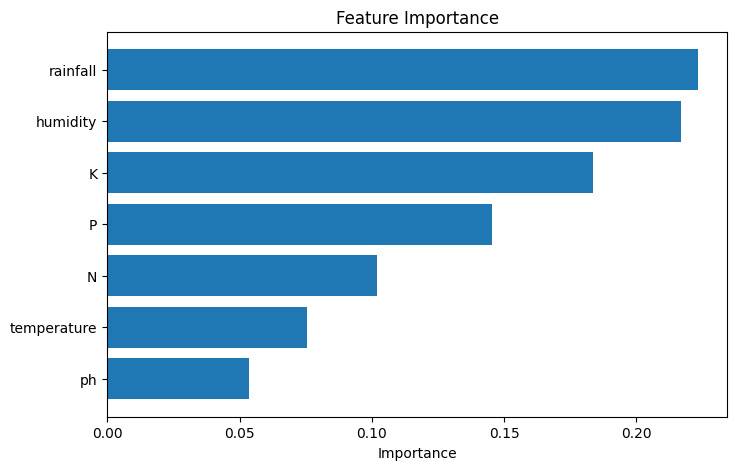

In [ ]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

features = X.columns

indices = np.argsort(importance)

plt.figure(figsize=(8,5))

plt.barh(range(len(indices)), importance[indices])

plt.yticks(range(len(indices)), features[indices])

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "crop_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(le, "label_encoder.pkl")

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [ ]:
print("="*50)

print("BEST MODEL")

print("="*50)

print(results_df)

best_name = results_df.iloc[0]["Model"]

print("\nSelected Model :", best_name)

print("Accuracy :", results_df.iloc[0]["Accuracy"])

print("="*50)

BEST MODEL
           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.995455   0.995671  0.995455  0.995452
3            MLP  0.988636   0.988745  0.988636  0.988635
4        XGBoost  0.986364   0.987407  0.986364  0.986210
1            SVM  0.984091   0.985610  0.984091  0.984038
2            KNN  0.979545   0.980356  0.979545  0.979283

Selected Model : Random Forest
Accuracy : 0.9954545454545455


phase2

In [ ]:
!pip install streamlit pyngrok joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd, joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

DATA_PATH = "/content/drive/MyDrive/Crop_recommendation.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)
df.drop_duplicates(inplace=True)

X = df.drop("label", axis=1)
y = df["label"]  # keep as strings — RandomForest handles this natively

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

print("Test Accuracy:", model.score(X_test, y_test))

joblib.dump(model, "/content/crop_model.pkl")
print("✅ Model saved to /content/crop_model.pkl")

Test Accuracy: 0.9954545454545455
✅ Model saved to /content/crop_model.pkl


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib, os, sqlite3, requests
from datetime import datetime, timedelta

st.set_page_config(
    page_title="🌾jai kisan",
    layout="wide",
    # Uncomment and modify these lines to change interface colors
    # primaryColor='#F63366', # A vibrant pink
    # backgroundColor='#FFFFFF', # White background
    # secondaryBackgroundColor='#F0F2F6', # Light grey for secondary elements
    # textColor='#262730', # Dark grey for text
    # base='light' # Use 'dark' for a dark theme
)

# ---------------- Load Model ----------------
try:
    model = joblib.load("/content/crop_model.pkl")
except Exception as e:
    st.error(f"❌ Model not found. Run the training cell in Colab first. ({e})")
    st.stop()

# ---------------- Database (persists in Drive if mounted) ----------------
if os.path.exists("/content/drive/MyDrive"):
    os.makedirs("/content/drive/MyDrive/AgriAI", exist_ok=True)
    DB_PATH = "/content/drive/MyDrive/AgriAI/farm_records.db"
else:
    DB_PATH = "/content/farm_records.db"

conn = sqlite3.connect(DB_PATH, check_same_thread=False)
conn.execute("""
CREATE TABLE IF NOT EXISTS records (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    farmer_name TEXT, location TEXT, record_date TEXT,
    predicted_crop TEXT, confidence REAL,
    nitrogen REAL, phosphorus REAL, potassium REAL,
    ph REAL, temperature REAL, humidity REAL, rainfall REAL
)
""")
conn.commit()

# ---------------- Crop Metadata ----------------
CROP_INFO = {
    "rice": {"season": "Kharif", "water": "High", "duration": 135},
    "maize": {"season": "Kharif/Rabi", "water": "Medium", "duration": 100},
    "chickpea": {"season": "Rabi", "water": "Low", "duration": 100},
    "kidneybeans": {"season": "Kharif", "water": "Medium", "duration": 95},
    "pigeonpeas": {"season": "Kharif", "water": "Low", "duration": 150},
    "mothbeans": {"season": "Kharif", "water": "Low", "duration": 75},
    "mungbean": {"season": "Kharif/Summer", "water": "Low", "duration": 65},
    "blackgram": {"season": "Kharif", "water": "Low", "duration": 90},
    "lentil": {"season": "Rabi", "water": "Low", "duration": 110},
    "pomegranate": {"season": "Perennial", "water": "Medium", "duration": 180},
    "banana": {"season": "Perennial", "water": "High", "duration": 300},
    "mango": {"season": "Perennial", "water": "Medium", "duration": 365},
    "grapes": {"season": "Perennial", "water": "Medium", "duration": 180},
    "watermelon": {"season": "Summer", "water": "Medium", "duration": 90},
    "muskmelon": {"season": "Summer", "water": "Medium", "duration": 90},
    "apple": {"season": "Perennial", "water": "Medium", "duration": 365},
    "orange": {"season": "Perennial", "water": "Medium", "duration": 300},
    "papaya": {"season": "Perennial", "water": "Medium", "duration": 270},
    "coconut": {"season": "Perennial", "water": "High", "duration": 365},
    "cotton": {"season": "Kharif", "water": "Medium", "duration": 165},
    "jute": {"season": "Kharif", "water": "High", "duration": 120},
    "coffee": {"season": "Perennial", "water": "Medium", "duration": 365},
}
DEFAULT_INFO = {"season": "Varies", "water": "Medium", "duration": 120}

# ---------------- Helper functions ----------------
def predict_crop(n, p, k, temp, hum, ph, rain):
    X = pd.DataFrame([[n, p, k, temp, hum, ph, rain]],
                      columns=["N", "P", "K", "temperature", "humidity", "ph", "rainfall"])
    probs = model.predict_proba(X)[0]
    classes = model.classes_
    order = np.argsort(probs)[::-1][:3]
    top3 = [(classes[i], round(probs[i] * 100, 2)) for i in order]
    crop, confidence = top3[0]
    return crop, confidence, top3

def get_weather(city, api_key):
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    r = requests.get(url, timeout=8).json()
    if str(r.get("cod")) != "200":
        raise ValueError(r.get("message", "Could not fetch weather"))
    temp = r["main"]["temp"]
    hum = r["main"]["humidity"]
    rain = r.get("rain", {}).get("1h", 0) * 24 if r.get("rain") else 80.0
    return temp, hum, rain

def fertilizer_guidance(n, p, k, ph):
    tips = []
    tips.append("🔴 Nitrogen is low — apply urea/compost." if n < 40 else
                 "🟡 Nitrogen is high — reduce N fertilizer." if n > 100 else
                 "🟢 Nitrogen level is adequate.")
    tips.append("🔴 Phosphorus is low — apply DAP/rock phosphate." if p < 30 else
                 "🟢 Phosphorus level is adequate.")
    tips.append("🔴 Potassium is low — apply MOP (potash)." if k < 30 else
                 "🟢 Potassium level is adequate.")
    if ph < 5.5:
        tips.append("🔴 Soil is acidic — apply agricultural lime.")
    elif ph > 7.5:
        tips.append("🔴 Soil is alkaline — apply gypsum/organic matter.")
    else:
        tips.append("🟢 Soil pH is in a healthy range.")
    return tips

def irrigation_guidance(rainfall, crop):
    info = CROP_INFO.get(crop, DEFAULT_INFO)
    need = info["water"]
    if rainfall < 75:
        return f"🔴 Rainfall is low — {crop.title()} needs {need} water. Plan additional irrigation."
    elif rainfall < 150:
        return f"🟡 Moderate rainfall. Monitor soil moisture ({need} water need)."
    return f"🟢 Rainfall is sufficient for {crop.title()}."

def build_schedule(crop, start):
    info = CROP_INFO.get(crop, DEFAULT_INFO)
    duration = info["duration"]
    harvest = start + timedelta(days=duration)
    d = lambda days: (start + timedelta(days=days)).strftime("%Y-%m-%d")
    rows = [
        {"Stage": "Land Preparation", "Date": f"{d(-14)} to {d(-1)}"},
        {"Stage": "Sowing", "Date": d(0)},
        {"Stage": "First Fertilizer Dose", "Date": d(15)},
        {"Stage": "Weeding", "Date": f"{d(20)} to {d(25)}"},
        {"Stage": "Second Fertilizer Dose", "Date": d(45)},
        {"Stage": "Pest Inspection", "Date": f"{d(30)} to {d(max(duration-15,31))}"},
        {"Stage": "Harvest", "Date": harvest.strftime("%Y-%m-%d")},
    ]
    return rows, duration, harvest

# ---------------- UI ----------------
st.title("🌾 J.A.R.V.I.S framing Assistant")
st.caption("Soil & weather–based crop recommendation, cultivation planning, and record keeping.")

with st.sidebar:
    st.header("👤 Farmer Details")
    farmer_name = st.text_input("Farmer Name", "tejesh")
    location = st.text_input("Location", "Vijayawada")
    st.divider()
    st.header("🌦️ Weather Source")
    weather_mode = st.radio("Choose", ["Fetch by city (live)", "Enter manually"])
    api_key = st.text_input("OpenWeatherMap API Key", type="password",
                             help="Free key at openweathermap.org")

tab1, tab2, tab3 = st.tabs(["🌱 Recommend Crop", "📅 Cultivation Schedule", "📋 Records"])

# ---- Tab 1: Recommend ----
with tab1:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Soil Nutrients")
        n = st.number_input("Nitrogen (N)", 0, 150, 90)
        p = st.number_input("Phosphorus (P)", 0, 150, 42)
        k = st.number_input("Potassium (K)", 0, 210, 43)
        ph = st.slider("Soil pH", 3.0, 10.0, 6.5, 0.1)
    with col2:
        st.subheader("Weather Conditions")
        if weather_mode == "Fetch by city (live)":
            city = st.text_input("City", location)
            if st.button("🔄 Fetch Live Weather"):
                if not api_key:
                    st.error("Enter your OpenWeatherMap API key in the sidebar.")
                else:
                    try:
                        t, h, r = get_weather(city, api_key)
                        st.session_state["weather"] = (t, h, r)
                        st.success(f"🌡️ {t}°C | 💧 {h}% | 🌧️ {r:.1f} mm")
                    except Exception as e:
                        st.error(f"Weather fetch failed: {e}")
            temp, hum, rain = st.session_state.get("weather", (25.0, 70.0, 100.0))
        else:
            temp = st.number_input("Temperature (°C)", -10.0, 55.0, 25.0)
            hum = st.number_input("Humidity (%)", 0.0, 100.0, 70.0)
            rain = st.number_input("Rainfall (mm)", 0.0, 500.0, 100.0)

    st.divider()
    if st.button("🔍 Recommend Crop", type="primary"):
        crop, confidence, top3 = predict_crop(n, p, k, temp, hum, ph, rain)
        st.session_state["last_crop"] = crop
        st.session_state["last_confidence"] = confidence
        st.session_state["last_top3"] = top3
        st.session_state["last_inputs"] = dict(n=n, p=p, k=k, ph=ph, temp=temp, hum=hum, rain=rain)

    if "last_crop" in st.session_state:
        crop = st.session_state["last_crop"]
        confidence = st.session_state["last_confidence"]
        top3 = st.session_state["last_top3"]
        inp = st.session_state["last_inputs"]

        st.success(f"### ✅ Recommended Crop: **{crop.title()}**  ({confidence}% confidence)")
        cols = st.columns(3)
        for i, (c, conf) in enumerate(top3):
            cols[i].metric(c.title(), f"{conf}%")

        info = CROP_INFO.get(crop, DEFAULT_INFO)
        st.write(f"**Season:** {info['season']}  |  **Water Need:** {info['water']}  |  **Typical Duration:** {info['duration']} days")

        st.markdown("#### 🧪 Fertilizer Guidance")
        for tip in fertilizer_guidance(inp["n"], inp["p"], inp["k"], inp["ph"]):
            st.write(tip)

        st.markdown("#### 💧 Irrigation Guidance")
        st.write(irrigation_guidance(inp["rain"], crop))

        if st.button("💾 Save this Recommendation as a Record"):
            conn.execute(
                "INSERT INTO records (farmer_name, location, record_date, predicted_crop, confidence, "
                "nitrogen, phosphorus, potassium, ph, temperature, humidity, rainfall) VALUES (?,?,?,?,?,?,?,?,?,?,?,?)",
                (farmer_name, location, datetime.now().strftime("%Y-%m-%d %H:%M"), crop, confidence,
                 inp["n"], inp["p"], inp["k"], inp["ph"], inp["temp"], inp["hum"], inp["rain"])
            )
            conn.commit()
            st.success("Record saved!")

# ---- Tab 2: Schedule ----
with tab2:
    st.subheader("📅 Cultivation Schedule Generator")
    crop_choice = st.text_input("Crop name", st.session_state.get("last_crop", "rice"))
    start = st.date_input("Sowing Start Date", datetime.now())
    if st.button("Generate Schedule"):
        rows, duration, harvest = build_schedule(crop_choice.lower().strip(),
                                                   datetime.combine(start, datetime.min.time()))
        st.write(f"**Total Duration:** {duration} days  |  **Estimated Harvest:** {harvest.strftime('%Y-%m-%d')}")
        st.table(pd.DataFrame(rows))

# ---- Tab 3: Records ----
with tab3:
    st.subheader("📋 Cultivation Records")
    c1, c2, c3 = st.columns(3)
    f_name = c1.text_input("Filter by Farmer")
    f_crop = c2.text_input("Filter by Crop")
    f_loc = c3.text_input("Filter by Location")

    q = "SELECT * FROM records WHERE 1=1"
    params = []
    if f_name: q += " AND farmer_name LIKE ?"; params.append(f"%{f_name}%")
    if f_crop: q += " AND predicted_crop LIKE ?"; params.append(f"%{f_crop}%")
    if f_loc: q += " AND location LIKE ?"; params.append(f"%{f_loc}%")
    q += " ORDER BY id DESC"

    cur = conn.execute(q, params)
    cols = [c[0] for c in cur.description]
    df_records = pd.DataFrame(cur.fetchall(), columns=cols)
    st.dataframe(df_records, use_container_width=True)

    if not df_records.empty:
        csv = df_records.to_csv(index=False).encode("utf-8")
        st.download_button("⬇️ Download Records as CSV", csv, "cultivation_records.csv", "text/csv")

        del_id = st.number_input("Record ID to delete", min_value=0, step=1)
        if st.button("🗑️ Delete Record"):
            conn.execute("DELETE FROM records WHERE id=?", (del_id,))
            conn.commit()
            st.warning(f"Deleted record {del_id}. Refresh the page to update the table.")

Writing app.py


In [ ]:
from pyngrok import ngrok
import time

ngrok.kill()  # clear any old tunnels

NGROK_AUTH_TOKEN = "YOUR_NGROK_AUTH_TOKEN"  # get free token: dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3GGLi3OYR216V0YAXNJz6VBdWxU_2GoZdWu4zhmcXFY8uF37p")

public_url = ngrok.connect(8501)
print("🌐 Your AI Farming Assistant is live at:", public_url)

get_ipython().system_raw("streamlit run app.py --server.port 8501 &")
time.sleep(5)
print("✅ Streamlit is running. Click the link above to open it.")

🌐 Your AI Farming Assistant is live at: NgrokTunnel: "https://dumpling-constant-viewing.ngrok-free.dev" -> "http://localhost:8501"
✅ Streamlit is running. Click the link above to open it.
